In [1]:
import wandb
from wandb.apis.public.runs import Run
import math
from typing import Any
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "one-shot-quant-11-12-25", "state": "finished"},
)

In [4]:
# NOTE: All runs use INT3 element dtype
def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["mode"] = run.config["quantisation"]["mode"]
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])
    d["vqa"] = run.summary["downstream.vqa.accuracy"]
    d["ai2d"] = run.summary["downstream.ai2d.accuracy"]
    d["chartqa"] = run.summary["downstream.chartqa.accuracy"]
    d["docvqa"] = run.summary["downstream.docvqa.anls"]
    
    # d["vqa_easy"] = run.summary["downstream.vqa.accuracy_easy"]
    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [6]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [7]:
df.sort_values(by=["n_steps", "lr_exponent", "mode"], ascending=True, inplace=True)
df = df.drop_duplicates()

In [8]:
df

,mode,n_steps,lr_exponent,vqa,ai2d,chartqa,docvqa,train_loss,val_loss
35,qat,0,-18.0,0.413411,0.132812,0.309570,0.061963,NaN,NaN
19,one-shot,256,-19.0,0.608724,0.234375,0.566406,0.168372,0.094007,0.133868
34,qat,256,-19.0,0.589518,0.268555,0.560547,0.308461,0.108831,0.161269
22,one-shot,256,-18.0,0.627279,0.263672,0.586914,0.239953,0.080372,0.134426
27,one-shot,256,-17.0,0.664714,0.204102,0.507812,0.506499,0.078183,0.109551
21,qat,256,-17.0,0.636719,0.105469,0.410156,0.405380,0.082545,0.118996
14,one-shot,256,-16.0,0.639323,0.267578,0.313477,0.306464,0.081865,0.149011
10,qat,256,-16.0,0.623372,0.316406,0.276367,0.452777,0.081101,0.156052
2,one-shot,256,-15.0,0.639648,0.177734,0.393555,0.392545,0.093313,0.164290
1,qat,256,-15.0,0.633138,0.297852,0.285156,0.299812,0.093576,0.139556


In [11]:
# Baseline (bflo16) results
from pathlib import Path
import json
from eval import vqa

path = Path().resolve().parent / "20251021-DownstreamTest/out/vqa/2025-10-21T17-49-27"
baseline = {}
for task_name in ["ai2d", "chartqa", "docvqa", "vqa"]:
    results = []
    with open(path / f"{task_name}.jsonl") as f:
        for line in f:
            results.append(json.loads(line))
    metric = vqa.TASKS[task_name].METRICS[0]
    out = [x[metric] for x in results]
    baseline[task_name] = sum(out) / len(out)

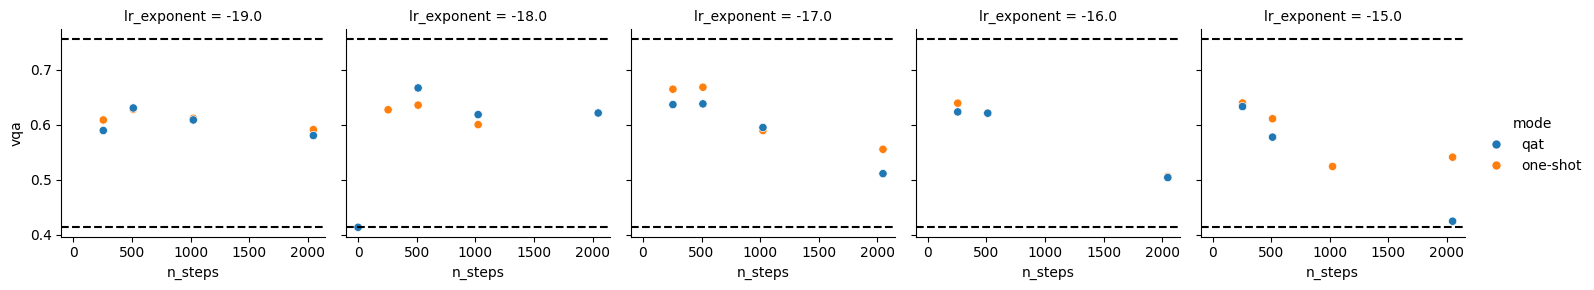

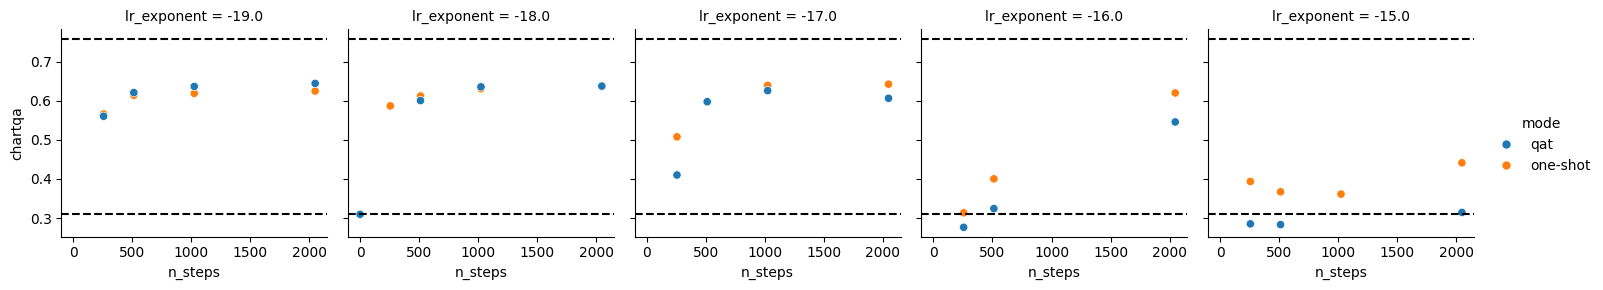

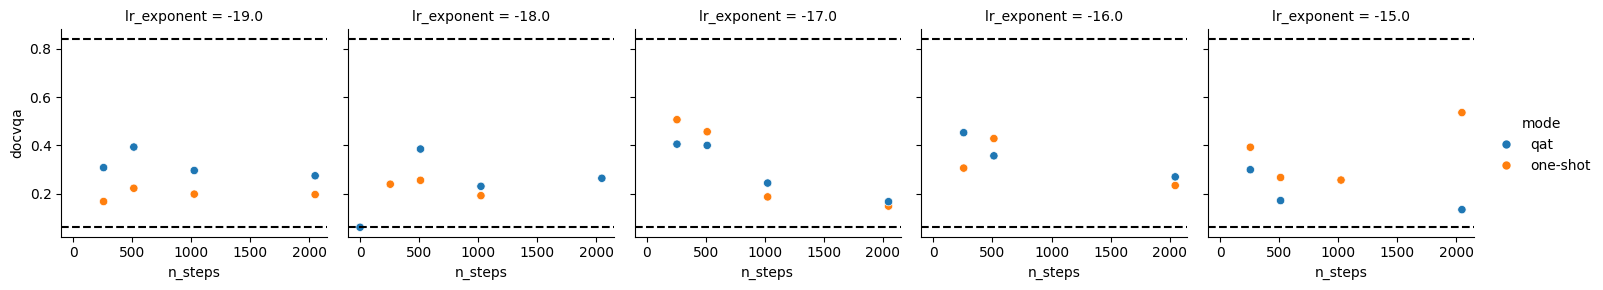

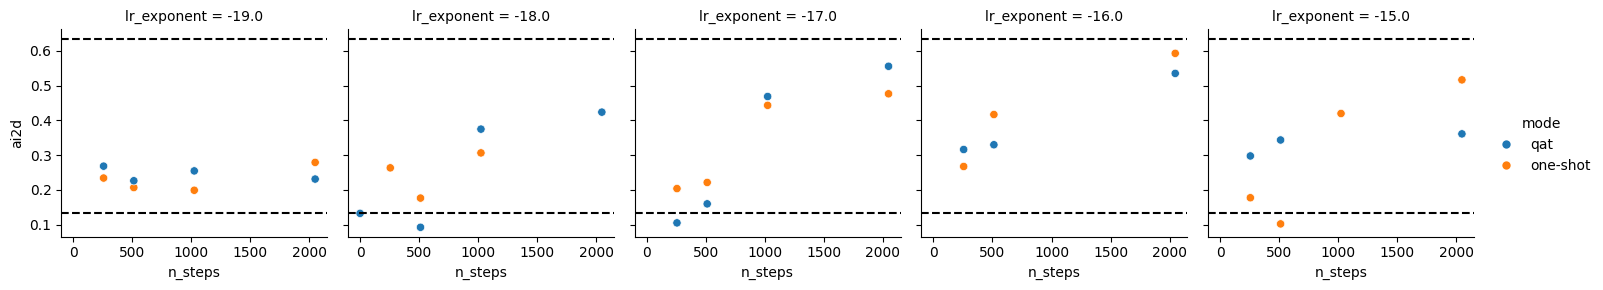

In [12]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(
        data=df,
        x="n_steps",
        y=task,
        hue="mode",
        col="lr_exponent",
        height=3
    )
    step_0 = df.loc[df["n_steps"] == 0, task].iloc[0]
    for ax in g.axes.flat:
        ax.axhline(step_0, linestyle="--", color="black")
        ax.axhline(baseline[task], linestyle="--", color="black")

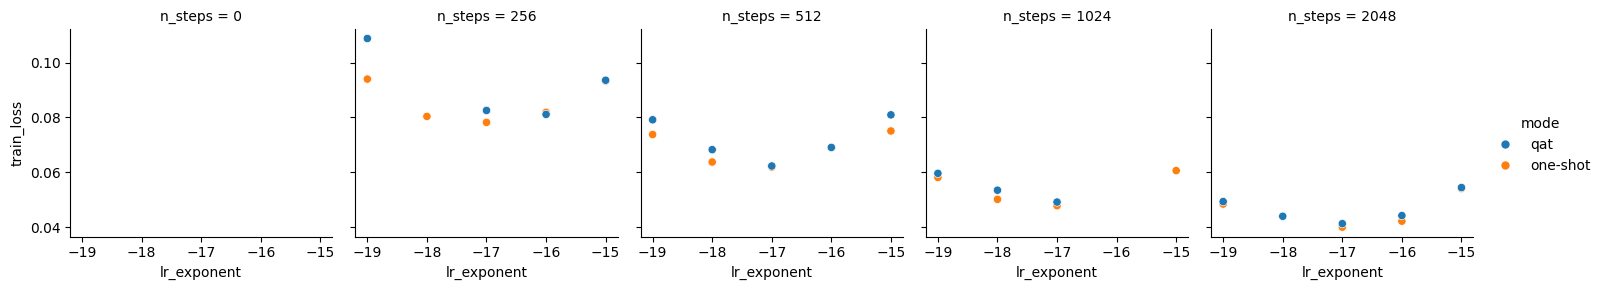

In [15]:
sns.relplot(
    data=df, x="lr_exponent", y="train_loss", col="n_steps", hue="mode", height=3
)

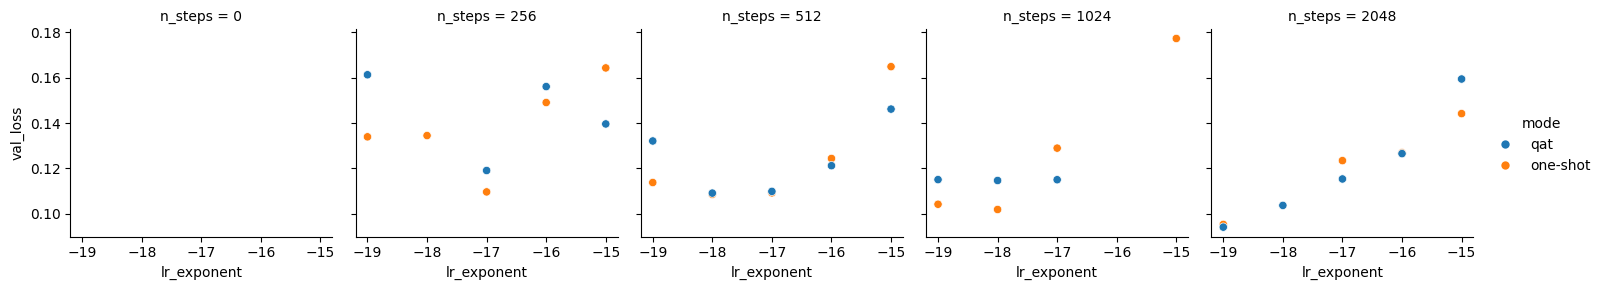

In [16]:
sns.relplot(data=df, x="lr_exponent", y="val_loss", col="n_steps", hue="mode", height=3)